# Chapter 11: Classification


In this notebook, we explore classification models and logistic regression.

We will study:

- binary classification
- logistic regression
- probabilities and thresholds
- confusion matrices
- accuracy, precision, and recall
- changing classification thresholds


## Binary Classification

In [1]:
# 0 = did not buy
# 1 = bought the product

purchase <- c(0, 0, 0, 1, 1, 1)

print(purchase)

[1] 0 0 0 1 1 1



Many classification problems involve only two categories.

Examples:
- spam or not spam
- fraud or legitimate transaction
- customer churn or no churn


## The Logistic Curve

In [2]:
# Create values for the horizontal axis

x <- seq(-10, 10, length.out = 300)

In [3]:
# Logistic (sigmoid) function

y <- 1 / (1 + exp(-x))

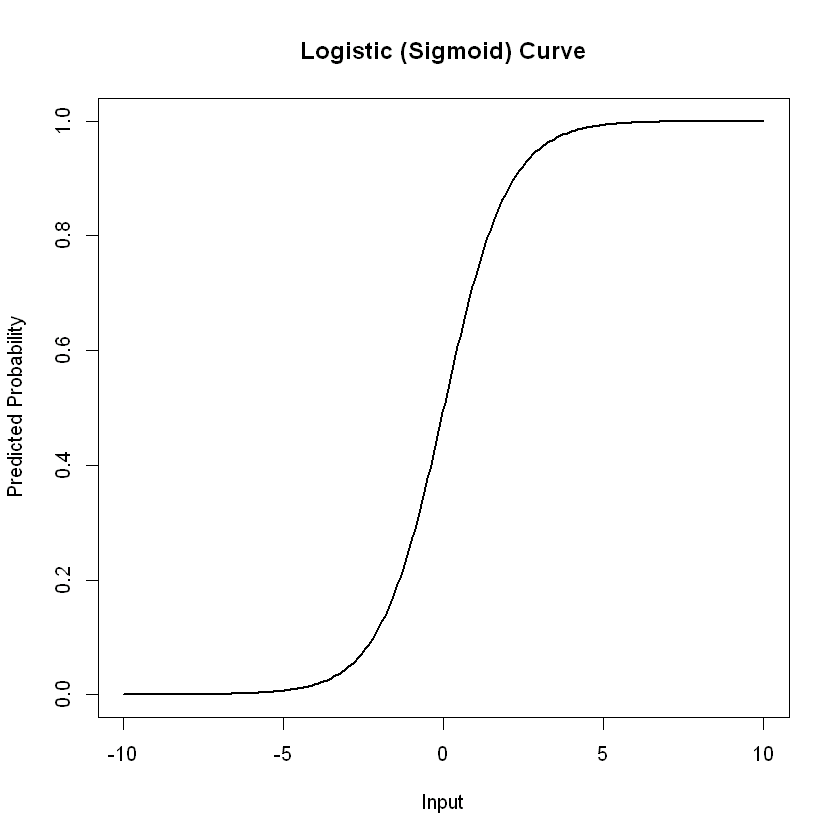

In [4]:
# Visualize the sigmoid curve

plot(
  x, y,
  type = "l",
  main = "Logistic (Sigmoid) Curve",
  xlab = "Input",
  ylab = "Predicted Probability",
  lwd = 2
)


The logistic curve keeps probabilities between 0 and 1.


## From Probabilities to Class Predictions

In [5]:
# Predicted probabilities

probabilities <- c(0.12, 0.34, 0.52, 0.81, 0.93)

print(probabilities)

[1] 0.12 0.34 0.52 0.81 0.93


In [6]:
# Use a threshold of 0.5

predictions <- ifelse(probabilities > 0.5, 1, 0)

print(predictions)

[1] 0 0 1 1 1



Probabilities above 0.5 become class 1.

Probabilities below 0.5 become class 0.


## Logistic Regression Example

In [7]:
# Study hours and exam results

study_hours <- c(
  1,2,3,4,5,
  6,7,8,9,10
)

exam_result <- c(
  0,0,0,1,0,
  1,1,1,1,1
)

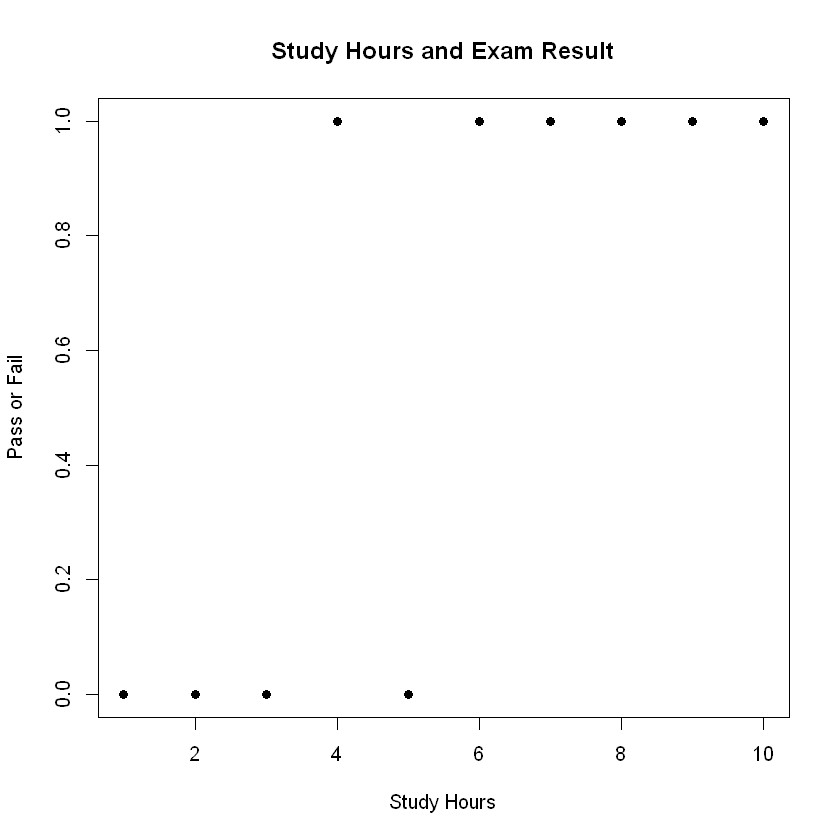

In [8]:
# Visualize the data

plot(
  study_hours, exam_result,
  main = "Study Hours and Exam Result",
  xlab = "Study Hours",
  ylab = "Pass or Fail",
  pch = 19
)

In [9]:
# Create a data frame for logistic regression

exam_data <- data.frame(
  study_hours = study_hours,
  exam_result = exam_result
)

In [10]:
# Create and train the logistic regression model

model <- glm(
  exam_result ~ study_hours,
  data = exam_data,
  family = binomial
)

In [11]:
# Predicted probabilities

probabilities <- predict(model, newdata = exam_data, type = "response")

print(head(probabilities, 5))

         1          2          3          4          5 
0.01067452 0.03791607 0.12583590 0.34460204 0.65759268 


In [12]:
# Probability of passing

pass_probability <- probabilities

print(pass_probability)

         1          2          3          4          5          6          7 
0.01067452 0.03791607 0.12583590 0.34460204 0.65759268 0.87523077 0.96243735 
         8          9         10 
0.98942777 0.99708316 0.99919974 


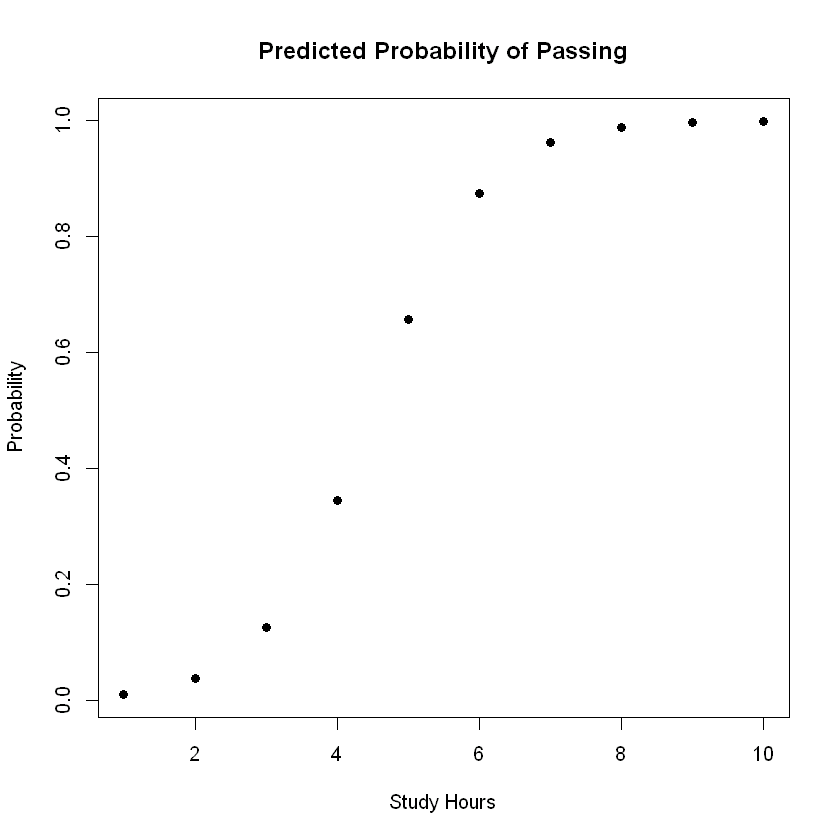

In [13]:
# Visualize predicted probabilities

plot(
  study_hours, pass_probability,
  main = "Predicted Probability of Passing",
  xlab = "Study Hours",
  ylab = "Probability",
  pch = 19
)

## Final Class Predictions

In [14]:
# Convert probabilities into class predictions

predictions <- ifelse(pass_probability > 0.5, 1, 0)

print(predictions)

 1  2  3  4  5  6  7  8  9 10 
 0  0  0  0  1  1  1  1  1  1 


## Confusion Matrix

In [15]:
# Compare actual values and predictions

matrix <- table(
  Actual = exam_result,
  Predicted = predictions
)

matrix

      Predicted
Actual 0 1
     0 3 1
     1 1 5


The confusion matrix contains:

- True Positives
- True Negatives
- False Positives
- False Negatives


## Accuracy

In [16]:
# Accuracy measures the fraction
# of correct predictions

accuracy <- mean(predictions == exam_result)

cat("Accuracy:", round(accuracy, 2), "\n")

Accuracy: 0.8 


## Precision

In [17]:
# Precision measures how trustworthy
# positive predictions are

tp <- sum(predictions == 1 & exam_result == 1)
fp <- sum(predictions == 1 & exam_result == 0)

precision <- tp / (tp + fp)

cat("Precision:", round(precision, 2), "\n")

Precision: 0.83 


## Recall

In [18]:
# Recall measures how well the model
# detects positive cases

fn <- sum(predictions == 0 & exam_result == 1)

recall <- tp / (tp + fn)

cat("Recall:", round(recall, 2), "\n")

Recall: 0.83 


## Changing the Threshold

In [19]:
# Use a larger threshold

threshold <- 0.8

high_threshold_predictions <- c()

In [20]:
# Convert probabilities using the new threshold

high_threshold_predictions <- ifelse(pass_probability > threshold, 1, 0)

print(high_threshold_predictions)

 1  2  3  4  5  6  7  8  9 10 
 0  0  0  0  0  1  1  1  1  1 


In [21]:
# Compare predictions at threshold 0.8

matrix <- table(
  Actual = exam_result,
  Predicted = high_threshold_predictions
)

matrix

      Predicted
Actual 0 1
     0 4 0
     1 1 5


Larger thresholds make the model more cautious
before predicting the positive class.


# Appendix F: Additional Concepts in Classification

## Why Linear Regression Is Not Enough

In [22]:
# Linear regression can produce impossible probabilities

predictions <- c(-0.3, 0.4, 1.2)

print(predictions)

[1] -0.3  0.4  1.2



Probabilities must remain between 0 and 1.

Logistic regression solves this problem using
the sigmoid function.


## The Logistic Function

In [23]:
# Logistic function example

x <- c(-5, -2, 0, 2, 5)

probabilities <- 1 / (1 + exp(-x))

print(probabilities)

[1] 0.006692851 0.119202922 0.500000000 0.880797078 0.993307149


## From Regression Output to Probability

In [24]:
# Regression outputs

regression_output <- c(-4, -1, 0, 2, 5)

print(regression_output)

[1] -4 -1  0  2  5


In [25]:
# Convert regression outputs into probabilities

probabilities <- 1 / (1 + exp(-regression_output))

print(probabilities)

[1] 0.01798621 0.26894142 0.50000000 0.88079708 0.99330715


## Dummy Variables

In [26]:
# Example categorical data

cities <- data.frame(
  City = c("Calgary", "Vancouver", "Toronto")
)

cities

City
<chr>
Calgary
Vancouver
Toronto


In [27]:
# Create a factor variable

city_factor <- factor(cities$City)

In [28]:
# Convert categories into numerical labels

cities$Encoded_City <- as.numeric(city_factor) - 1

cities

City,Encoded_City
<chr>,<dbl>
Calgary,0
Vancouver,2
Toronto,1


In [29]:
# See the classes and numbers assigned to them

mapping <- data.frame(
  City = levels(city_factor),
  Encoded_City = 0:(length(levels(city_factor)) - 1)
)

mapping

City,Encoded_City
<chr>,<int>
Calgary,0
Toronto,1
Vancouver,2


In [30]:
# Convert categories into dummy variables

dummy_variables <- model.matrix(
  ~ City - 1,
  data = cities
)

dummy_variables

,CityCalgary,CityToronto,CityVancouver
1,1,0,0
2,0,0,1
3,0,1,0



Dummy variables convert categories into numerical variables
that machine learning models can use.
